In [224]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ------------------------------------------------------------
# 0) Load the FINAL dataset created by data_cleaning_and_alignment.ipynb
# ------------------------------------------------------------
DATA_PATH = "../1_data/processed/final_dataset.csv"   # <- matches your cleaning notebook export

df = pd.read_csv(DATA_PATH)

# ------------------------------------------------------------
# 1) Standardize types and sort
# ------------------------------------------------------------
df["month"] = pd.to_datetime(df["month"])
df = df.sort_values("month").reset_index(drop=True)

# Ensure numeric
for c in ["vacancies", "Unemployment", "theta"]:
    df[c] = pd.to_numeric(df[c], errors="coerce")

# Basic integrity checks (fail fast = PhD-level discipline)
required = ["month", "vacancies", "Unemployment", "theta"]
missing = [c for c in required if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}. Available columns: {list(df.columns)}")

# Avoid divide-by-zero issues if any appear downstream
df["Unemployment"] = df["Unemployment"].replace(0, np.nan)

# ------------------------------------------------------------
# 2) Period labels (aligned to your descriptive notebook)
# ------------------------------------------------------------
df["period"] = np.where(
    df["month"] < pd.Timestamp("2020-03-01"),
    "Pre-COVID",
    "Post-COVID"
)

# Optional: exclude the gap window exactly like descriptive.ipynb (only if it exists)
gap_mask = (df["month"] >= "2020-04-01") & (df["month"] <= "2020-09-30")
df = df.loc[~gap_mask].copy()

# ------------------------------------------------------------
# 3) Quick audit snapshot (always keep this in diagnostics)
# ------------------------------------------------------------
audit = pd.DataFrame({
    "rows": [len(df)],
    "start_month": [df["month"].min()],
    "end_month": [df["month"].max()],
    "missing_vacancies": [df["vacancies"].isna().sum()],
    "missing_unemployment": [df["Unemployment"].isna().sum()],
    "missing_theta": [df["theta"].isna().sum()],
    "period_counts": [df["period"].value_counts().to_dict()]
})

audit


,rows,start_month,end_month,missing_vacancies,missing_unemployment,missing_theta,period_counts
0,111,2015-04-01,2024-12-01,0,0,0,"{'Pre-COVID': 59, 'Post-COVID': 52}"


## 1) Vacancy vs Unemployment Relationship (Regime Comparison)

This figure visualizes the empirical relationship between unemployment (U_t) and job vacancies (V_t), segmented by regime.

If the labour market operates on a stable Beveridge curve:
- Observations should lie on a single downward-sloping cloud.

If structural mismatch increased post-COVID:
- The cloud shifts outward (higher V for the same U).

This visual test precedes formal regression.


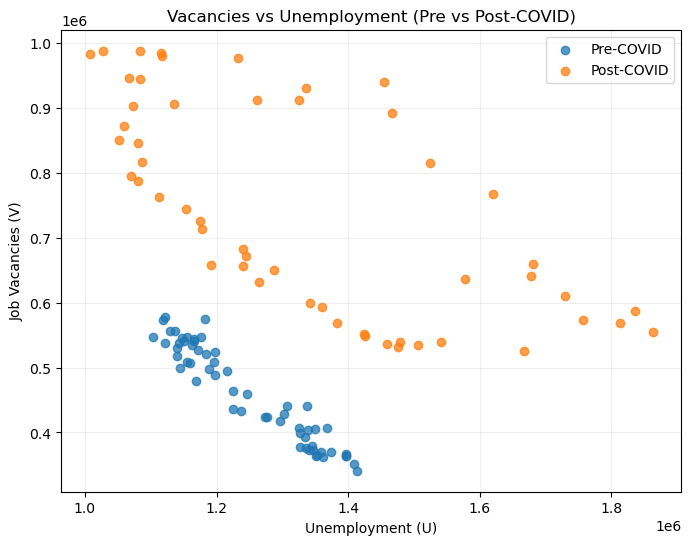

In [225]:
plt.figure(figsize=(8,6))

for p in ["Pre-COVID", "Post-COVID"]:
    subset = df[df["period"] == p]
    plt.scatter(subset["Unemployment"],
                subset["vacancies"],
                alpha=0.75,
                label=p)

plt.xlabel("Unemployment (U)")
plt.ylabel("Job Vacancies (V)")
plt.title("Vacancies vs Unemployment (Pre vs Post-COVID)")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


In [226]:
# Drop any missing values
reg_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

X = sm.add_constant(reg_df["Unemployment"])
y = reg_df["vacancies"]

model_full = sm.OLS(y, X).fit()

model_full.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              vacancies   R-squared:                       0.077
Model:                            OLS   Adj. R-squared:                  0.068
Method:                 Least Squares   F-statistic:                     9.054
Date:                Sun, 15 Feb 2026   Prob (F-statistic):            0.00326
Time:                        11:39:42   Log-Likelihood:                -1499.5
No. Observations:                 111   AIC:                             3003.
Df Residuals:                     109   BIC:                             3008.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         9.514e+05   1.21e+05      7.881      0.000    7.12e+05    1.19e+06
Unemployment    -0.2788      0.093     -3.009      0.003      -0.462      -0.095
==============================================================================
Omnibus:                       14.637   Durbin-Watson:                   0.025
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               10.968
Skew:                           0.655   Prob(JB):                      0.00415
Kurtosis:                       2.190   Cond. No.                     9.22e+06
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 9.22e+06. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 2) Beveridge Curve (Full Sample: 2015–2024)

This figure presents the aggregate Beveridge relationship over the full sample:

$$
V_t = \alpha + \beta U_t + \varepsilon_t
$$


This provides the baseline vacancy–unemployment relationship before considering structural regime differences.

If the curve appears noisy or weakly fitted, this supports the earlier finding that the full-sample relationship masks regime instability.


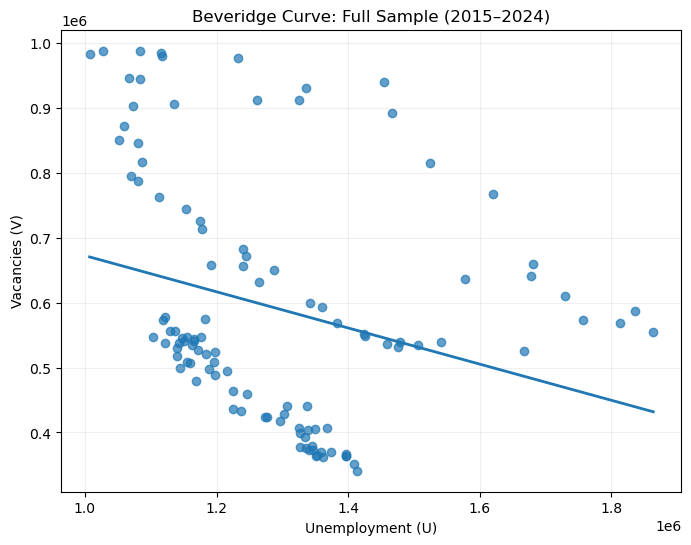

In [227]:
# Use full regression model already estimated (model_full)

full_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

plt.figure(figsize=(8,6))

# Scatter (full sample)
plt.scatter(full_df["Unemployment"],
            full_df["vacancies"],
            alpha=0.7)

# Fitted line
u_min = full_df["Unemployment"].min()
u_max = full_df["Unemployment"].max()
u_grid = np.linspace(u_min, u_max, 100)

plt.plot(u_grid,
         model_full.predict(sm.add_constant(u_grid)),
         linewidth=2)

plt.xlabel("Unemployment (U)")
plt.ylabel("Vacancies (V)")
plt.title("Beveridge Curve: Full Sample (2015–2024)")
plt.grid(alpha=0.2)
plt.show()


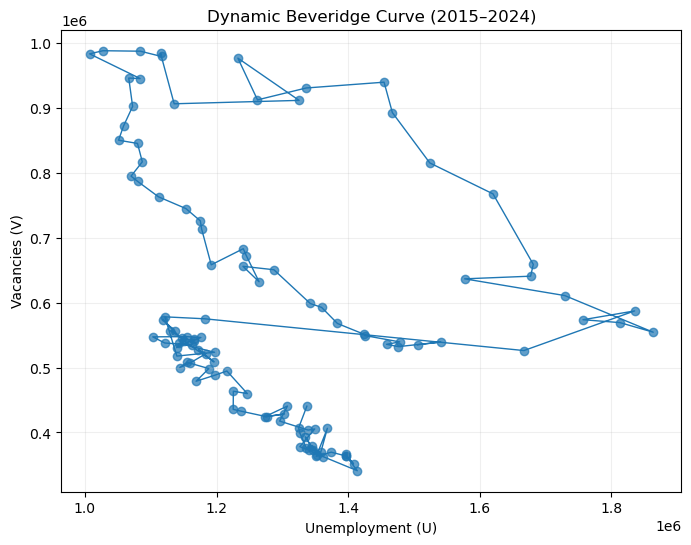

In [228]:
path_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(path_df["Unemployment"],
            path_df["vacancies"],
            alpha=0.7)

# Connect points chronologically
plt.plot(path_df["Unemployment"],
         path_df["vacancies"],
         linewidth=1)

plt.xlabel("Unemployment (U)")
plt.ylabel("Vacancies (V)")
plt.title("Dynamic Beveridge Curve (2015–2024)")
plt.grid(alpha=0.2)
plt.show()


## 3) Beveridge Relationship by Regime (Pre vs Post)

The regression is estimated separately for:

- Pre-COVID period
- Post-COVID period

This tests whether:
- The slope changed
- The intercept shifted upward
- Matching efficiency weakened

If Post-COVID vacancies are systematically higher at similar unemployment levels, this indicates an outward Beveridge shift consistent with structural mismatch.


In [229]:
# Split datasets
pre_df = df[df["period"] == "Pre-COVID"].dropna(subset=["vacancies", "Unemployment"])
post_df = df[df["period"] == "Post-COVID"].dropna(subset=["vacancies", "Unemployment"])

# Pre model
model_pre = sm.OLS(pre_df["vacancies"],
                   sm.add_constant(pre_df["Unemployment"])).fit()

# Post model
model_post = sm.OLS(post_df["vacancies"],
                    sm.add_constant(post_df["Unemployment"])).fit()

print("Pre-COVID Model")
print(model_pre.summary())

print("\nPost-COVID Model")
print(model_post.summary())


Pre-COVID Model
                            OLS Regression Results                            
Dep. Variable:              vacancies   R-squared:                       0.919
Model:                            OLS   Adj. R-squared:                  0.917
Method:                 Least Squares   F-statistic:                     642.4
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           1.02e-32
Time:                        11:39:43   Log-Likelihood:                -670.99
No. Observations:                  59   AIC:                             1346.
Df Residuals:                      57   BIC:                             1350.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.381e+06   3.65e+

In [230]:
post_df = df[df["period"] == "Post-COVID"].dropna(subset=["vacancies", "Unemployment"])

print("Number of Post-COVID observations:", len(post_df))

X_post = sm.add_constant(post_df["Unemployment"])
y_post = post_df["vacancies"]

model_post = sm.OLS(y_post, X_post).fit()

print(model_post.summary())


Number of Post-COVID observations: 52
                            OLS Regression Results                            
Dep. Variable:              vacancies   R-squared:                       0.440
Model:                            OLS   Adj. R-squared:                  0.429
Method:                 Least Squares   F-statistic:                     39.26
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           8.43e-08
Time:                        11:39:43   Log-Likelihood:                -681.40
No. Observations:                  52   AIC:                             1367.
Df Residuals:                      50   BIC:                             1371.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const     

In [231]:
# Keep only Pre and Post (already done)
test_df = df[df["period"].isin(["Pre-COVID", "Post-COVID"])].copy()

# Dummy for Post
test_df["D_post"] = (test_df["period"] == "Post-COVID").astype(int)

# Interaction term
test_df["U_interact"] = test_df["Unemployment"] * test_df["D_post"]

# Regression
X_int = sm.add_constant(test_df[["Unemployment", "D_post", "U_interact"]])
y_int = test_df["vacancies"]

model_interaction = sm.OLS(y_int, X_int).fit()

model_interaction.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              vacancies   R-squared:                       0.801
Model:                            OLS   Adj. R-squared:                  0.795
Method:                 Least Squares   F-statistic:                     143.5
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           2.37e-37
Time:                        11:39:43   Log-Likelihood:                -1414.4
No. Observations:                 111   AIC:                             2837.
Df Residuals:                     107   BIC:                             2848.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
================================================================================
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
const         1.381e+06   1.44e+05      9.624      0.000     1.1e+06    1.67e+06
Unemployment    -0.7373      0.115     -6.437      0.000      -0.964      -0.510
D_post        -5.66e+04   1.58e+05     -0.359      0.721    -3.7e+05    2.56e+05
U_interact       0.3004      0.124      2.415      0.017       0.054       0.547
==============================================================================
Omnibus:                        4.650   Durbin-Watson:                   0.164
Prob(Omnibus):                  0.098   Jarque-Bera (JB):                4.075
Skew:                           0.380   Prob(JB):                        0.130
Kurtosis:                       3.551   Cond. No.                     3.90e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 3.9e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## 4) Regression Results Summary (Full sample vs Regimes)


This section summarizes the empirical findings from the Beveridge relationship analysis.

### 1) Full-Sample Beveridge Regression

$$
V_t = \alpha + \beta U_t + \varepsilon_t
$$


- The slope coefficient on unemployment is negative and statistically significant.
- However, the explanatory power is low (R² ≈ 0.08).
- Residual diagnostics indicate strong serial correlation.

Interpretation:
While the traditional Beveridge logic holds directionally, unemployment alone does not explain vacancy dynamics well over the full 2015–2024 sample. This suggests structural instability.

---

### 2) Pre-COVID Regime (Baseline Structure)

- Slope (β) ≈ −0.74  
- R² ≈ 0.92  

Interpretation:
Before COVID, unemployment explained nearly all vacancy variation. The labour market operated along a tight and stable Beveridge curve consistent with cyclical dynamics.

---

### 3) Post-COVID Regime

- Slope (β) ≈ −0.44  
- R² ≈ 0.44  

Interpretation:
The relationship weakened substantially after COVID. Vacancies became less responsive to unemployment, and explanatory power dropped by more than half.

This indicates reduced matching efficiency and possible structural frictions.

---

### 4) Formal Structural Shift Test

$$
V_t = \alpha + \beta U_t + \gamma D_t + \delta (U_t \times D_t) + \varepsilon_t
$$


- The interaction term (U × Post) is positive and statistically significant.
- The intercept shift is not statistically significant.

Interpretation:
The Beveridge curve did not shift vertically in a pure level sense. Instead, the slope flattened significantly after COVID.

This confirms a statistically meaningful structural change in labour market dynamics.

---

### Interim Conclusion

Pre-COVID labour market tightness was primarily cyclical and strongly anchored to unemployment.

Post-COVID dynamics reflect a structurally weaker vacancy–unemployment relationship, consistent with increased mismatch, sectoral reallocation, or persistent hiring frictions.


## 5) Beveridge Curve Visualization (Pre vs Post-COVID)

This figure plots the empirical Beveridge curve separately for the Pre-COVID and Post-COVID regimes.

The fitted lines are derived from:
$$
V_t = \alpha_{pre} + \beta_{pre} U_t + \varepsilon_t
$$


$$
V_t = \alpha_{post} + \beta_{post} U_t + \varepsilon_t
$$


If the Post-COVID slope is flatter, this indicates reduced vacancy responsiveness to unemployment and weaker matching efficiency.


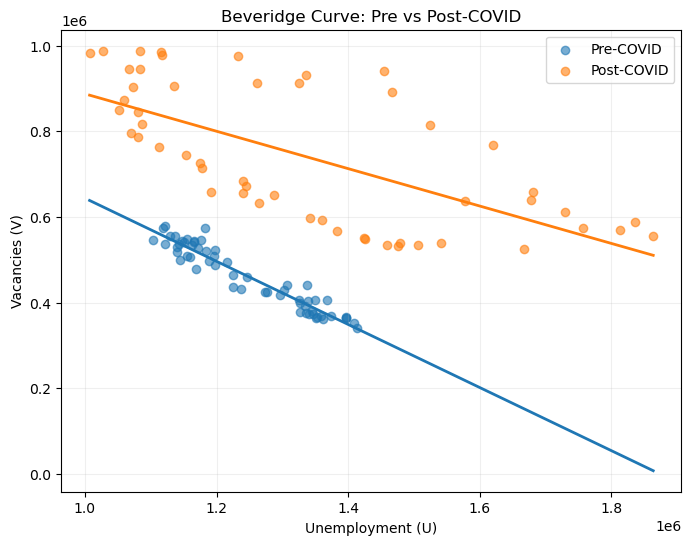

In [232]:
plt.figure(figsize=(8,6))

# Scatter points
plt.scatter(pre_df["Unemployment"], pre_df["vacancies"],
            alpha=0.6, label="Pre-COVID")

plt.scatter(post_df["Unemployment"], post_df["vacancies"],
            alpha=0.6, label="Post-COVID")

# Common U range
u_min = min(pre_df["Unemployment"].min(), post_df["Unemployment"].min())
u_max = max(pre_df["Unemployment"].max(), post_df["Unemployment"].max())
u_grid = np.linspace(u_min, u_max, 100)

# Fitted lines
plt.plot(u_grid,
         model_pre.predict(sm.add_constant(u_grid)),
         linewidth=2)

plt.plot(u_grid,
         model_post.predict(sm.add_constant(u_grid)),
         linewidth=2)

plt.xlabel("Unemployment (U)")
plt.ylabel("Vacancies (V)")
plt.title("Beveridge Curve: Pre vs Post-COVID")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 6) Rolling 12-Month Correlation

To assess dynamic stability of the Beveridge relationship, a 12-month rolling correlation is computed:

$$
\mathrm{Corr}^{(12)}_t(V, U)
$$


If the labour market operates under a stable matching structure, correlation should remain persistently negative.

Large fluctuations or weakening correlation suggest structural instability.


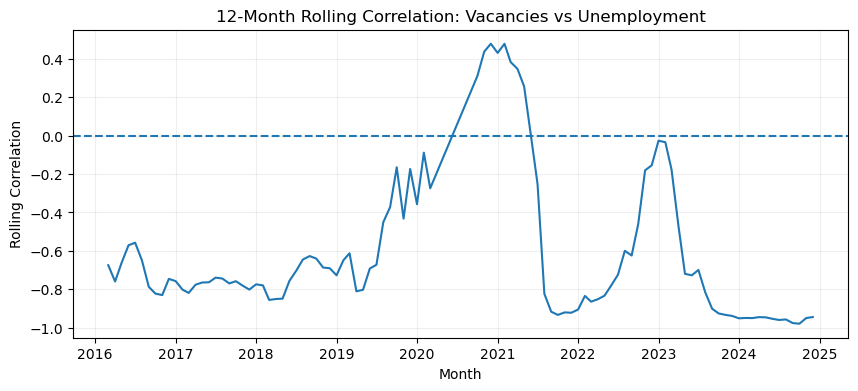

In [233]:
roll_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

roll_df["rolling_corr_12"] = (
    roll_df["vacancies"]
    .rolling(12)
    .corr(roll_df["Unemployment"])
)

plt.figure(figsize=(10,4))
plt.plot(roll_df["month"], roll_df["rolling_corr_12"])
plt.axhline(0, linestyle="--")
plt.title("12-Month Rolling Correlation: Vacancies vs Unemployment")
plt.xlabel("Month")
plt.ylabel("Rolling Correlation")
plt.grid(alpha=0.2)
plt.show()


## 7) Lead–Lag Correlation Analysis

To examine dynamic timing, the following correlations are estimated:

$$
\mathrm{Corr}(V_t, U_{t+k}), 
\quad k \in \{1,3,6\}
$$


If vacancies systematically lead unemployment (strong negative correlations),
this supports demand-driven adjustment.

Weak or unstable lead–lag relationships suggest structural frictions.


In [234]:
lag_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

results = []

for k in [1, 3, 6]:
    corr = lag_df["vacancies"].corr(lag_df["Unemployment"].shift(-k))
    results.append({"Lag (months)": k, "Corr(V_t, U_t+k)": corr})

pd.DataFrame(results)



,Lag (months),"Corr(V_t, U_t+k)"
0,1,-0.305859
1,3,-0.351620
2,6,-0.372233


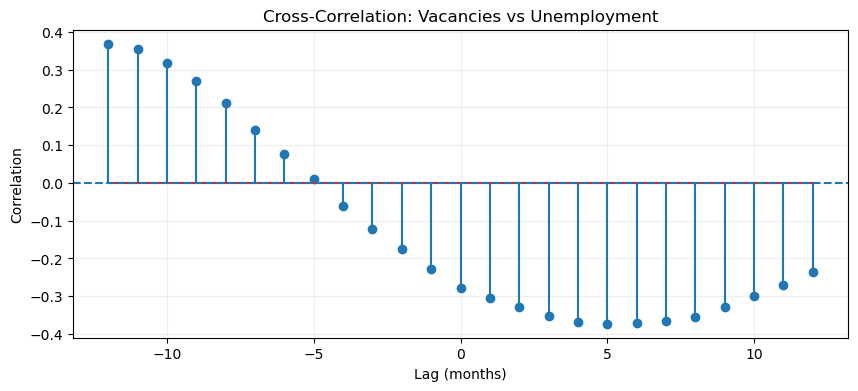

In [235]:
lag_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

max_lag = 12
lags = range(-max_lag, max_lag + 1)

corr_values = []

for k in lags:
    if k >= 0:
        corr = lag_df["vacancies"].corr(lag_df["Unemployment"].shift(-k))
    else:
        corr = lag_df["vacancies"].shift(k).corr(lag_df["Unemployment"])
    corr_values.append(corr)

# Plot
plt.figure(figsize=(10,4))
plt.stem(lags, corr_values)
plt.axhline(0, linestyle="--")
plt.title("Cross-Correlation: Vacancies vs Unemployment")
plt.xlabel("Lag (months)")
plt.ylabel("Correlation")
plt.grid(alpha=0.2)
plt.show()


## 8) Tightness Driver Decomposition

Since:

$$
\theta_t = \frac{V_t}{U_t}
$$


Taking log differences:

$$
\Delta \ln(\theta_t) = \Delta \ln(V_t) - \Delta \ln(U_t)
$$


This decomposition separates tightness changes into:

- Vacancy contribution: \(\Delta \ln(V_t)\)
- Unemployment contribution: \(-\Delta \ln(U_t)\)

This identifies whether imbalance is demand-driven or supply-driven.


In [236]:
decomp_df = df.dropna(subset=["vacancies", "Unemployment", "theta"]).copy()

decomp_df["dln_theta"] = np.log(decomp_df["theta"]).diff()
decomp_df["dln_V"] = np.log(decomp_df["vacancies"]).diff()
decomp_df["dln_U"] = np.log(decomp_df["Unemployment"]).diff()

decomp_df["contrib_V"] = decomp_df["dln_V"]
decomp_df["contrib_U"] = -decomp_df["dln_U"]

# Average contribution by regime
decomp_summary = (
    decomp_df.groupby("period")[["contrib_V", "contrib_U", "dln_theta"]]
    .mean()
)

decomp_summary


,contrib_V,contrib_U,dln_theta
period,,,
Post-COVID,-0.001389,-0.004652,-0.006041
Pre-COVID,0.004602,0.002127,0.006729


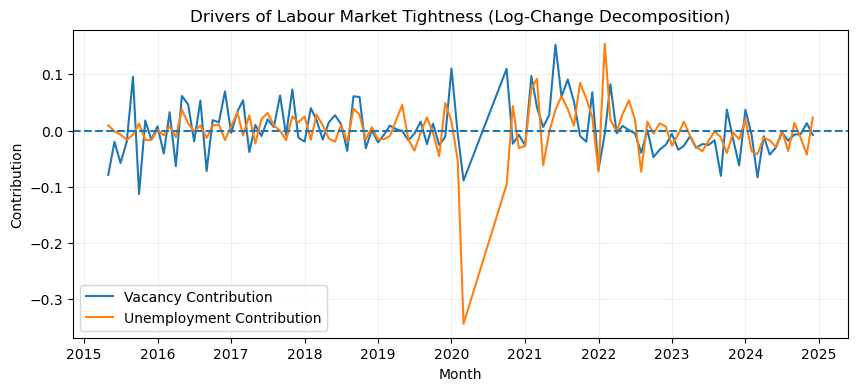

In [237]:
# Ensure decomposition dataframe exists
plot_df = decomp_df.copy()

plt.figure(figsize=(10,4))

plt.plot(plot_df["month"], plot_df["contrib_V"],
         label="Vacancy Contribution")

plt.plot(plot_df["month"], plot_df["contrib_U"],
         label="Unemployment Contribution")

plt.axhline(0, linestyle="--")
plt.title("Drivers of Labour Market Tightness (Log-Change Decomposition)")
plt.xlabel("Month")
plt.ylabel("Contribution")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 9) Average Contribution by Regime

This figure compares average contributions of vacancies and unemployment to tightness changes across:

- Pre-COVID
- Post-COVID

This directly highlights structural shifts in the drivers of imbalance.


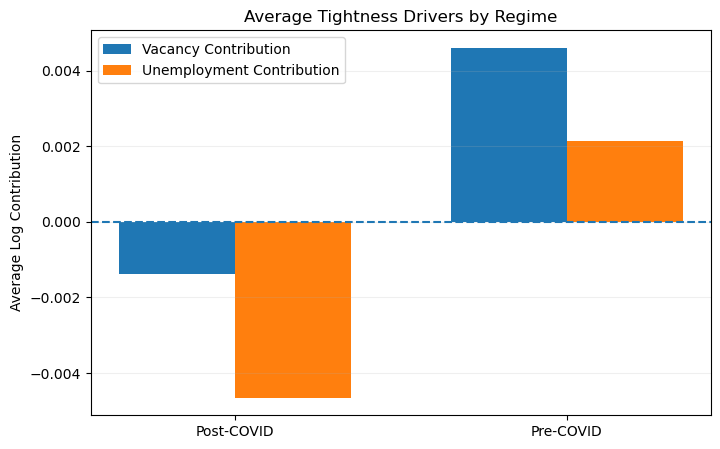

In [238]:
summary = decomp_summary.reset_index()

plt.figure(figsize=(8,5))

x = np.arange(len(summary["period"]))
width = 0.35

plt.bar(x - width/2, summary["contrib_V"], width, label="Vacancy Contribution")
plt.bar(x + width/2, summary["contrib_U"], width, label="Unemployment Contribution")

plt.xticks(x, summary["period"])
plt.axhline(0, linestyle="--")
plt.title("Average Tightness Drivers by Regime")
plt.ylabel("Average Log Contribution")
plt.legend()
plt.grid(axis="y", alpha=0.2)

plt.show()


## 10) Persistence of Labour Market Tightness (AR(1))

To assess persistence in labour market imbalance, the following model is estimated:

$$
\theta_t = \alpha + \phi \theta_{t-1} + \varepsilon_t
$$


If \(\phi\) is close to 1, tightness shocks persist over time.
Lower values suggest faster mean reversion.


In [239]:
ar_df = df.dropna(subset=["theta"]).copy()
ar_df["theta_lag1"] = ar_df["theta"].shift(1)

ar_df = ar_df.dropna(subset=["theta", "theta_lag1"])

X_ar = sm.add_constant(ar_df["theta_lag1"])
y_ar = ar_df["theta"]

model_ar1 = sm.OLS(y_ar, X_ar).fit()

model_ar1.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  theta   R-squared:                       0.961
Model:                            OLS   Adj. R-squared:                  0.961
Method:                 Least Squares   F-statistic:                     2696.
Date:                Sun, 15 Feb 2026   Prob (F-statistic):           3.30e-78
Time:                        11:39:44   Log-Likelihood:                 207.82
No. Observations:                 110   AIC:                            -411.6
Df Residuals:                     108   BIC:                            -406.2
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0099      0.010      1.028      0.306      -0.009       0.029
theta_lag1     0.9797      0.019     51.921      0.000       0.942       1.017
==============================================================================
Omnibus:                       22.653   Durbin-Watson:                   1.750
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               98.447
Skew:                          -0.474   Prob(JB):                     4.19e-22
Kurtosis:                       7.537   Cond. No.                         6.61
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

C:\Users\Vision\AppData\Local\Temp\ipykernel_13348\1822908690.py:10: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y_vals = model_ar1.params[0] + model_ar1.params[1] * x_vals


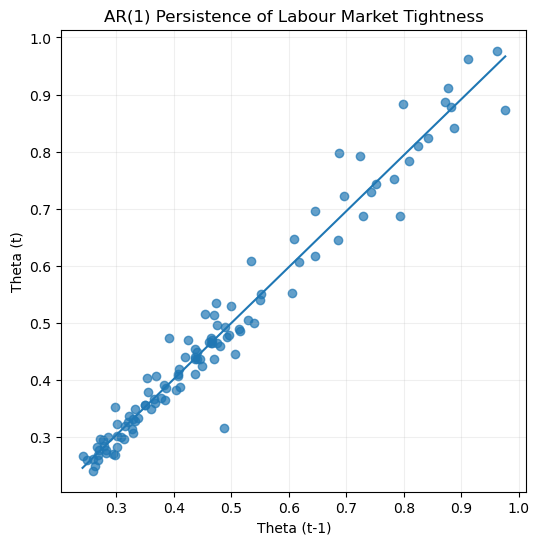

In [240]:
ar_vis = ar_df.copy()

plt.figure(figsize=(6,6))
plt.scatter(ar_vis["theta_lag1"], ar_vis["theta"], alpha=0.7)

# Fitted line
x_vals = np.linspace(ar_vis["theta_lag1"].min(),
                     ar_vis["theta_lag1"].max(), 100)

y_vals = model_ar1.params[0] + model_ar1.params[1] * x_vals

plt.plot(x_vals, y_vals)

plt.xlabel("Theta (t-1)")
plt.ylabel("Theta (t)")
plt.title("AR(1) Persistence of Labour Market Tightness")
plt.grid(alpha=0.2)
plt.show()


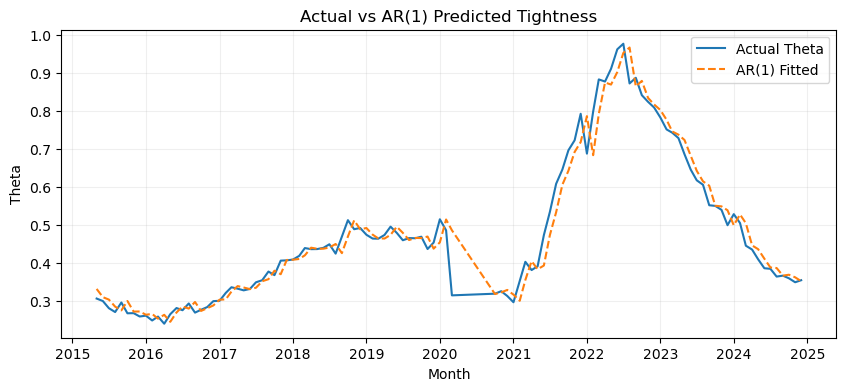

In [241]:
ar_vis["theta_hat"] = model_ar1.predict(
    sm.add_constant(ar_vis["theta_lag1"])
)

plt.figure(figsize=(10,4))
plt.plot(ar_vis["month"], ar_vis["theta"], label="Actual Theta")
plt.plot(ar_vis["month"], ar_vis["theta_hat"], linestyle="--", label="AR(1) Fitted")
plt.title("Actual vs AR(1) Predicted Tightness")
plt.xlabel("Month")
plt.ylabel("Theta")
plt.legend()
plt.grid(alpha=0.2)
plt.show()


## 11) Residual Mismatch Over Time

Mismatch is defined as:

$$
\text{Mismatch}_t = V_t - \hat{V}_t
$$


where:

$$
\hat{V}_t = \alpha + \beta U_t
$$


Positive mismatch indicates vacancies exceeding what unemployment predicts.


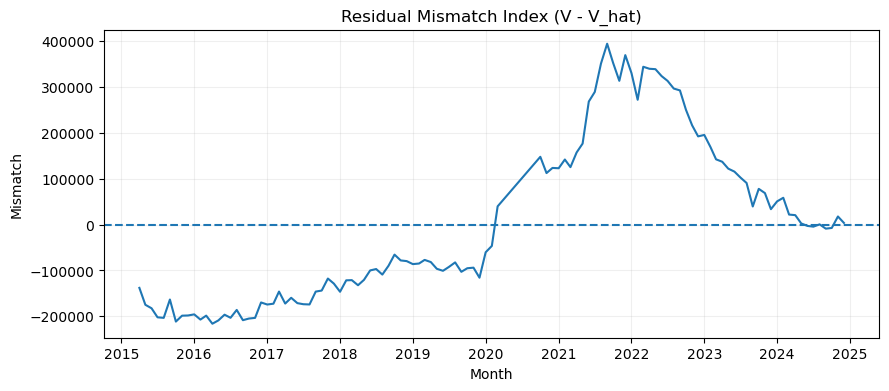

In [242]:
# Ensure full-sample model exists (model_full)
mis_df = df.dropna(subset=["vacancies", "Unemployment"]).copy()

X_full = sm.add_constant(mis_df["Unemployment"])
mis_df["V_hat"] = model_full.predict(X_full)

mis_df["mismatch"] = mis_df["vacancies"] - mis_df["V_hat"]

plt.figure(figsize=(10,4))
plt.plot(mis_df["month"], mis_df["mismatch"])
plt.axhline(0, linestyle="--")
plt.title("Residual Mismatch Index (V - V_hat)")
plt.xlabel("Month")
plt.ylabel("Mismatch")
plt.grid(alpha=0.2)
plt.show()


## 12) Average Residual Mismatch by Regime

This figure compares average mismatch between:

- Pre-COVID
- Post-COVID

Persistent positive values post-COVID indicate structural excess vacancies.


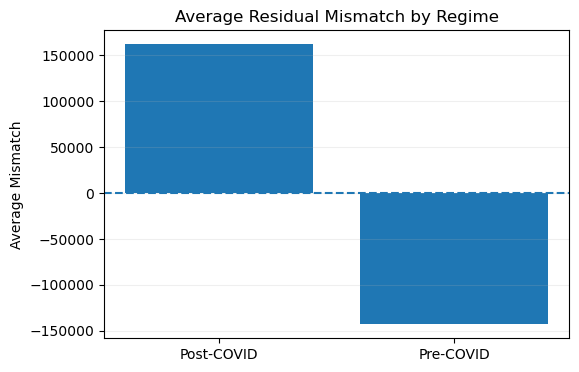

,period,mismatch
0,Post-COVID,162186.968159
1,Pre-COVID,-142944.446513


In [243]:
mis_df["period"] = np.where(
    mis_df["month"] < "2020-03-01",
    "Pre-COVID",
    "Post-COVID"
)

mis_avg = mis_df.groupby("period")["mismatch"].mean().reset_index()

plt.figure(figsize=(6,4))
plt.bar(mis_avg["period"], mis_avg["mismatch"])
plt.axhline(0, linestyle="--")
plt.title("Average Residual Mismatch by Regime")
plt.ylabel("Average Mismatch")
plt.grid(axis="y", alpha=0.2)
plt.show()

mis_avg
